# **Patient summary and claim file load**

In [2]:
# install Java and PySpark
!apt-get update -qq
!apt-get install -y openjdk-11-jdk > /dev/null

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [1]:
# Import and read beneficiary data with total rows and columns count
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("Payment_variance_prediction").getOrCreate()

beneficiary_sum=(spark.read
                 .option("header",True)
                 .option("inferschema",True)
                 .csv("/content/drive/MyDrive/Big Data Project/Beneficiary summary.csv"))
print("Total rows",beneficiary_sum.count())
print("Total columns",len(beneficiary_sum.columns))
beneficiary_sum.printSchema()

Mounted at /content/drive
Total rows 116352
Total columns 32
root
 |-- DESYNPUF_ID: string (nullable = true)
 |-- BENE_BIRTH_DT: integer (nullable = true)
 |-- BENE_DEATH_DT: integer (nullable = true)
 |-- BENE_SEX_IDENT_CD: integer (nullable = true)
 |-- BENE_RACE_CD: integer (nullable = true)
 |-- BENE_ESRD_IND: string (nullable = true)
 |-- SP_STATE_CODE: integer (nullable = true)
 |-- BENE_COUNTY_CD: integer (nullable = true)
 |-- BENE_HI_CVRAGE_TOT_MONS: integer (nullable = true)
 |-- BENE_SMI_CVRAGE_TOT_MONS: integer (nullable = true)
 |-- BENE_HMO_CVRAGE_TOT_MONS: integer (nullable = true)
 |-- PLAN_CVRG_MOS_NUM: integer (nullable = true)
 |-- SP_ALZHDMTA: integer (nullable = true)
 |-- SP_CHF: integer (nullable = true)
 |-- SP_CHRNKIDN: integer (nullable = true)
 |-- SP_CNCR: integer (nullable = true)
 |-- SP_COPD: integer (nullable = true)
 |-- SP_DEPRESSN: integer (nullable = true)
 |-- SP_DIABETES: integer (nullable = true)
 |-- SP_ISCHMCHT: integer (nullable = true)
 |-- SP

In [2]:
# Import and read inpatient claim data with total rows and columns count
inpatient_claim=(spark.read
                 .option("header",True)
                 .option("inferschema",True)
                 .csv("/content/drive/MyDrive/Big Data Project/Inpatient Claims.csv"))
print("Total Rows",inpatient_claim.count())
print("Total Columns",len(inpatient_claim.columns))
inpatient_claim.printSchema()

Total Rows 66773
Total Columns 81
root
 |-- DESYNPUF_ID: string (nullable = true)
 |-- CLM_ID: long (nullable = true)
 |-- SEGMENT: integer (nullable = true)
 |-- CLM_FROM_DT: integer (nullable = true)
 |-- CLM_THRU_DT: integer (nullable = true)
 |-- PRVDR_NUM: string (nullable = true)
 |-- CLM_PMT_AMT: double (nullable = true)
 |-- NCH_PRMRY_PYR_CLM_PD_AMT: double (nullable = true)
 |-- AT_PHYSN_NPI: long (nullable = true)
 |-- OP_PHYSN_NPI: long (nullable = true)
 |-- OT_PHYSN_NPI: long (nullable = true)
 |-- CLM_ADMSN_DT: integer (nullable = true)
 |-- ADMTNG_ICD9_DGNS_CD: string (nullable = true)
 |-- CLM_PASS_THRU_PER_DIEM_AMT: double (nullable = true)
 |-- NCH_BENE_IP_DDCTBL_AMT: double (nullable = true)
 |-- NCH_BENE_PTA_COINSRNC_LBLTY_AM: double (nullable = true)
 |-- NCH_BENE_BLOOD_DDCTBL_LBLTY_AM: double (nullable = true)
 |-- CLM_UTLZTN_DAY_CNT: integer (nullable = true)
 |-- NCH_BENE_DSCHRG_DT: integer (nullable = true)
 |-- CLM_DRG_CD: string (nullable = true)
 |-- ICD9_DG

# **Data cleaning and tranformation**

In [5]:
#Renamed some columns of beneficiary data to make those easily identifiable
rename_beneficiary={
    "DESYNPUF_ID":"beneficiary_id",
    "BENE_BIRTH_DT":"birth_date",
    "BENE_DEATH_DT":"death_date",
    "BENE_SEX_IDENT_CD":"gender","BENE_RACE_CD":"race_code",
    "BENE_ESRD_IND":"endstage_renal_disease_indi",
    "SP_STATE_CODE":"state",
    "BENE_COUNTY_CD":"county",
    "BENE_HI_CVRAGE_TOT_MONS":"months_partA_coverage",
    "BENE_SMI_CVRAGE_TOT_MONS":"months_partB_coverage",
    "BENE_HMO_CVRAGE_TOT_MONS":"months_hmo_coverage",
    "PLAN_CVRG_MOS_NUM":"months_partD_coverage",
    "SP_ALZHDMTA":"alzheimer",
    "SP_CHF":"heart_failure",
    "SP_CHRNKIDN":"chronic_kidney_disease",
    "SP_CNCR":"cancer",
    "SP_COPD":"COPD",
    "SP_DEPRESSN":"depression",
    "SP_DIABETES":"diabetes",
    "SP_ISCHMCHT":"ischemic_heart_disease",
    "SP_OSTEOPRS":"osteoporosis",
    "SP_RA_OA":"rheumatoid_arthritis",
    "SP_STRKETIA":"stroke"
    }

In [6]:
#Renamed some columns of claim data to make those easily identifiable
rename_inpatient = {
    "DESYNPUF_ID": "beneficiary_id",
    "CLM_ID": "claim_id",
    "SEGMENT": "claim_line_segment",
    "CLM_FROM_DT": "claim_start_date",
    "CLM_THRU_DT": "claim_end_date",
    "PRVDR_NUM": "provider_number",
    "CLM_PMT_AMT": "claim_payment_amount",
    "NCH_PRMRY_PYR_CLM_PD_AMT": "primary_payer_paid_amount",
    "AT_PHYSN_NPI": "attending_physician_npi",
    "OP_PHYSN_NPI": "operating_physician_npi",
    "OT_PHYSN_NPI": "other_physician_npi",
    "CLM_ADMSN_DT": "admission_date",
    "ADMTNG_ICD9_DGNS_CD": "admitting_diagnosis_code",
    "CLM_PASS_THRU_PER_DIEM_AMT": "pass_through_per_diem_amount",
    "NCH_BENE_IP_DDCTBL_AMT": "inpatient_deductible_amount",
    "NCH_BENE_PTA_COINSRNC_LBLTY_AM": "part_a_coinsurance_amount",
    "NCH_BENE_BLOOD_DDCTBL_LBLTY_AM": "blood_deductible_amount",
    "CLM_UTLZTN_DAY_CNT": "utilization_day_count",
    "NCH_BENE_DSCHRG_DT": "beneficiary_discharge_date",
    "CLM_DRG_CD": "drg_code"
}


In [7]:
# Function to rename columns in bulk
def rename_columns(df, rename_dict):
    for old_col, new_col in rename_dict.items():
        if old_col in df.columns:
            df = df.withColumnRenamed(old_col, new_col)
    return df

inpatient_claim = rename_columns(inpatient_claim, rename_inpatient)
beneficiary_sum = rename_columns(beneficiary_sum, rename_beneficiary)

In [8]:
#Join each beneficiary to respective claim data using left join so that we dont loose any claim data
beneficiary_claim = inpatient_claim.join(beneficiary_sum, on="beneficiary_id", how="left")
beneficiary_claim.show(3, truncate=False)
print("Total Columns:",len(beneficiary_claim.columns))
print("Total Rows:",beneficiary_claim.count())

+----------------+---------------+------------------+----------------+--------------+---------------+--------------------+-------------------------+-----------------------+-----------------------+-------------------+--------------+------------------------+----------------------------+---------------------------+-------------------------+-----------------------+---------------------+--------------------------+--------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+----------+----------+----------+----------+----------+----------+----------+----------+----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----

In [9]:
#count number of NULL in each variables
from pyspark.sql.functions import col,sum
null_sum=beneficiary_claim.select(*(sum(col(c).isNull().cast("int")).alias(c) for c in beneficiary_claim.columns))
null_sum.show()

+--------------+--------+------------------+----------------+--------------+---------------+--------------------+-------------------------+-----------------------+-----------------------+-------------------+--------------+------------------------+----------------------------+---------------------------+-------------------------+-----------------------+---------------------+--------------------------+--------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+----------+----------+----------+----------+----------+----------+----------+----------+----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+--

Drop Fully NULL columns

In [10]:
total_rows=beneficiary_claim.count()
#find columns where all values are null
empty_col=[c for c in beneficiary_claim.columns if beneficiary_claim.filter(col(c).isNull()).count()==total_rows]
beneficiary_claim=beneficiary_claim.drop(*empty_col)
print("Total Columns:",len(beneficiary_claim.columns))


Total Columns: 67


In [11]:
beneficiary_claim.show(3, truncate=False)

+----------------+---------------+------------------+----------------+--------------+---------------+--------------------+-------------------------+-----------------------+-----------------------+-------------------+--------------+------------------------+----------------------------+---------------------------+-------------------------+-----------------------+---------------------+--------------------------+--------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+----------+----------+------+---------+---------------------------+-----+------+---------------------+---------------------+-------------------+---------------------+---------+-------------+----------------------+------+----+----------+--------+----------------------+------------+--------------------+------+-----------+---------+-

In [12]:
# dropping rows where claim start date and end date are NULL as they are only 68 in numbers so it statistically insignificant
# Remove rows where both dates are NULL
beneficiary_claim = beneficiary_claim.filter(~(col("claim_start_date").isNull() & col("claim_end_date").isNull()))

In [13]:
#drop death_date column as it has 66518 NULL which will not help in our model
beneficiary_claim=beneficiary_claim.drop("death_date")

In [14]:
# Filter rows where attending_physician_npi is NULL
# but at least one of the other two NPI columns is NOT NULL
missing_attending = beneficiary_claim.filter(
    (col("attending_physician_npi").isNull()) &
    (
        col("operating_physician_npi").isNotNull() |
        col("other_physician_npi").isNotNull()
    )
).select("attending_physician_npi", "operating_physician_npi", "other_physician_npi")

# Show the filtered result
missing_attending.show(3, truncate=False)


+-----------------------+-----------------------+-------------------+
|attending_physician_npi|operating_physician_npi|other_physician_npi|
+-----------------------+-----------------------+-------------------+
|NULL                   |7586101692             |NULL               |
|NULL                   |2853715584             |NULL               |
|NULL                   |9207619283             |NULL               |
+-----------------------+-----------------------+-------------------+
only showing top 3 rows



I want to keep those records where attending_physician_npi is NULL for later investigation on why that is NULL and other NPIs like operating and other physician npi has data. I want to check if there are specific DRGs that doesn't need attending npi.

In [15]:
#Drop claims without admitting diagnosis code as they are incomplete and as they are categorical and cannot be imputed
#records are excluded for further analysis
# Drop rows where admitting_diagnosis_code is null
beneficiary_claim = beneficiary_claim.filter(col("admitting_diagnosis_code").isNotNull())


In [16]:
print("Total Rows:",beneficiary_claim.count())
null_sum=beneficiary_claim.select(*(sum(col(c).isNull().cast("int")).alias(c) for c in beneficiary_claim.columns))
null_sum.show()

Total Rows: 66174
+--------------+--------+------------------+----------------+--------------+---------------+--------------------+-------------------------+-----------------------+-----------------------+-------------------+--------------+------------------------+----------------------------+---------------------------+-------------------------+-----------------------+---------------------+--------------------------+--------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+----------+------+---------+---------------------------+-----+------+---------------------+---------------------+-------------------+---------------------+---------+-------------+----------------------+------+----+----------+--------+----------------------+------------+--------------------+------+-----------+---------+---

In [17]:
beneficiary_claim.show(3, truncate=False)

+----------------+---------------+------------------+----------------+--------------+---------------+--------------------+-------------------------+-----------------------+-----------------------+-------------------+--------------+------------------------+----------------------------+---------------------------+-------------------------+-----------------------+---------------------+--------------------------+--------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+----------+------+---------+---------------------------+-----+------+---------------------+---------------------+-------------------+---------------------+---------+-------------+----------------------+------+----+----------+--------+----------------------+------------+--------------------+------+-----------+---------+---------+--

In [18]:
# for every diseases like diabetes , depression etc the labels are "Yes" for 1 and "No" for 2
# convert "No" to 0 so that it would be asier for modeling
from pyspark.sql.functions import when

chronic_columns = [
    "alzheimer", "heart_failure", "chronic_kidney_disease", "cancer", "COPD",
    "depression", "diabetes", "ischemic_heart_disease",
    "osteoporosis", "rheumatoid_arthritis", "stroke"
]

# Replace all 2s with 0s
for column in chronic_columns:
    beneficiary_claim = beneficiary_claim.withColumn(
        column,
        when(col(column) == 2, 0).otherwise(col(column))
    )
beneficiary_claim.show(3, truncate=False)

+----------------+---------------+------------------+----------------+--------------+---------------+--------------------+-------------------------+-----------------------+-----------------------+-------------------+--------------+------------------------+----------------------------+---------------------------+-------------------------+-----------------------+---------------------+--------------------------+--------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+----------+------+---------+---------------------------+-----+------+---------------------+---------------------+-------------------+---------------------+---------+-------------+----------------------+------+----+----------+--------+----------------------+------------+--------------------+------+-----------+---------+---------+--

In [19]:
# label state columns code to actual state based on CMS data dictionary
from pyspark.sql.functions import col, when
from pyspark.sql.functions import create_map, lit
from itertools import chain

# State code mapping dictionary
state_map = {
    1: "AL", 2: "AK", 3: "AZ", 4: "AR", 5: "CA", 6: "CO", 7: "CT", 8: "DE", 9: "DC", 10: "FL",
    11: "GA", 12: "HI", 13: "ID", 14: "IL", 15: "IN", 16: "IA", 17: "KS", 18: "KY", 19: "LA",
    20: "ME", 21: "MD", 22: "MA", 23: "MI", 24: "MN", 25: "MS", 26: "MO", 27: "MT", 28: "NE",
    29: "NV", 30: "NH", 31: "NJ", 32: "NM", 33: "NY", 34: "NC", 35: "ND", 36: "OH", 37: "OK",
    38: "OR", 39: "PA", 41: "RI", 42: "SC", 43: "SD", 44: "TN", 45: "TX", 46: "UT", 47: "VT",
    49: "VA", 50: "WA", 51: "WV", 52: "WI", 53: "WY", 54: "Others"
}

mapping_expr = create_map([lit(x) for x in chain(*state_map.items())])

beneficiary_claim = beneficiary_claim.withColumn(
    "state_abbr",
    mapping_expr[col("state")]
)


In [20]:
# map race code to actual race so that I can analyze disease prevelance based on race, later I will convert back with one hot encoding for model building
from pyspark.sql.functions import when, col

beneficiary_claim = beneficiary_claim.withColumn(
    "race",
    when(col("race_code") == 1, "White")
    .when(col("race_code") == 2, "Black")
    .when(col("race_code") == 3, "Others")
    .when(col("race_code") == 5, "Hispanic")
    .otherwise("Unknown")
)

In [21]:
# map male =1 and female =0 for gender column
beneficiary_claim = beneficiary_claim.withColumn(
    "benef_gender",
    when(col("gender") == 2, 0).otherwise(1)
)

In [22]:
# format all date columns "claim_start_date","claim_end_date","admission_date","birth_date"
from pyspark.sql.functions import to_date

# all date columns to convert
date_cols = ["claim_start_date", "claim_end_date", "admission_date", "birth_date","beneficiary_discharge_date"]

# Convert integer to string first, then to proper date format (yyyyMMdd)
for c in date_cols:
    beneficiary_claim = beneficiary_claim.withColumn(
        c,
        to_date(col(c).cast("string"), "yyyyMMdd")
    )
# Verify the result
beneficiary_claim.select(*date_cols).show(5)


+----------------+--------------+--------------+----------+--------------------------+
|claim_start_date|claim_end_date|admission_date|birth_date|beneficiary_discharge_date|
+----------------+--------------+--------------+----------+--------------------------+
|      2010-03-12|    2010-03-13|    2010-03-12|1923-05-01|                2010-03-13|
|      2009-04-12|    2009-04-18|    2009-04-12|1943-01-01|                2009-04-18|
|      2009-08-31|    2009-09-02|    2009-08-31|1943-01-01|                2009-09-02|
|      2009-09-17|    2009-09-20|    2009-09-17|1943-01-01|                2009-09-20|
|      2010-06-26|    2010-07-01|    2010-06-26|1943-01-01|                2010-07-01|
+----------------+--------------+--------------+----------+--------------------------+
only showing top 5 rows



In [23]:
# as we can see in above table claim_start_date and admission_date columns are similar so lets verify if every rows are same
#if both columns have same records we can drop one column
from pyspark.sql.functions import col

same_date_count = beneficiary_claim.filter(
    col("admission_date") == col("claim_start_date")
).count()

total_rows = beneficiary_claim.count()

print(f"Rows with identical dates: {same_date_count}")
print(f"Total rows: {total_rows}")
print(f"Percentage matching: {(same_date_count / total_rows) * 100:.2f}%")


Rows with identical dates: 66122
Total rows: 66174
Percentage matching: 99.92%


In [24]:
# as we can see in above table claim_end_date and beneficiary_discharge_date columns are similar so lets verify if every rows are same
#if both columns have same records we can drop one column
from pyspark.sql.functions import col

same_date_count_ = beneficiary_claim.filter(
    col("beneficiary_discharge_date") == col("claim_end_date")
).count()

total_rows = beneficiary_claim.count()

print(f"Rows with identical dates: {same_date_count_}")
print(f"Total rows: {total_rows}")
print(f"Percentage matching: {(same_date_count_ / total_rows) * 100:.2f}%")

Rows with identical dates: 66174
Total rows: 66174
Percentage matching: 100.00%


In [25]:
#As 99.92% of data are matching we can drop one of them
beneficiary_claim = beneficiary_claim.drop("admission_date")

In [26]:
#As 100% of data are matching in claim_end_date and discharge date we can drop one of them
beneficiary_claim = beneficiary_claim.drop("beneficiary_discharge_date")

In [27]:
beneficiary_claim.show(3, truncate=False)

+----------------+---------------+------------------+----------------+--------------+---------------+--------------------+-------------------------+-----------------------+-----------------------+-------------------+------------------------+----------------------------+---------------------------+-------------------------+-----------------------+---------------------+--------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+----------+------+---------+---------------------------+-----+------+---------------------+---------------------+-------------------+---------------------+---------+-------------+----------------------+------+----+----------+--------+----------------------+------------+--------------------+------+-----------+---------+---------+-----------+---------+---------+------------

In [28]:
#column claim_line_segment is 1 for each records so we can remove this column as well
beneficiary_claim.select("claim_line_segment").distinct().show()
beneficiary_claim = beneficiary_claim.drop("claim_line_segment")
beneficiary_claim.show(3, truncate=False)

+------------------+
|claim_line_segment|
+------------------+
|                 1|
+------------------+

+----------------+---------------+----------------+--------------+---------------+--------------------+-------------------------+-----------------------+-----------------------+-------------------+------------------------+----------------------------+---------------------------+-------------------------+-----------------------+---------------------+--------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+----------+------+---------+---------------------------+-----+------+---------------------+---------------------+-------------------+---------------------+---------+-------------+----------------------+------+----+----------+--------+----------------------+------------+-----------------

In [29]:
#Show records where state_abbr is NY that is string variable
from pyspark.sql.functions import col
beneficiary_claim.filter(col("state_abbr") == "TN").show(5, truncate=False)

+----------------+---------------+----------------+--------------+---------------+--------------------+-------------------------+-----------------------+-----------------------+-------------------+------------------------+----------------------------+---------------------------+-------------------------+-----------------------+---------------------+--------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+----------+------+---------+---------------------------+-----+------+---------------------+---------------------+-------------------+---------------------+---------+-------------+----------------------+------+----+----------+--------+----------------------+------------+--------------------+------+-----------+---------+---------+-----------+---------+---------+------------+----------+-------

The **provider_number (eg:3302XJ)** variable encodes detailed information about the hospital.
Positions 1–2 indicate the state where the provider is located.
Positions 3–6 represent the **type and sequence of the hospital** within that state.

If the third position is an **alpha character (M, R, S, T, U, V, W, Y, or Z)**, the facility is **excluded from the Medicare Inpatient Prospective Payment System (IPPS) — meaning its reimbursement is not based on MS-DRGs**.

In our dataset, all provider numbers have numeric values in positions 3 and 4 (ranging between 0001–0879), which correspond to Short-Term (General and Specialty) Hospitals that are paid under IPPS.
For these hospitals, inpatient claims use Type of Bill (TOB) 11X, while ESRD facilities use TOB 72X under separate outpatient rules.

*Analyzing Variables with No Significant Relationship to Provider Reimbursement.
**Based on domain knolwedge** I have a hypothesis thatcoverage months do not impact the claim amount or financial variables. To prove that I want to make a scatter plot and see if there is trend or not between those variables.*

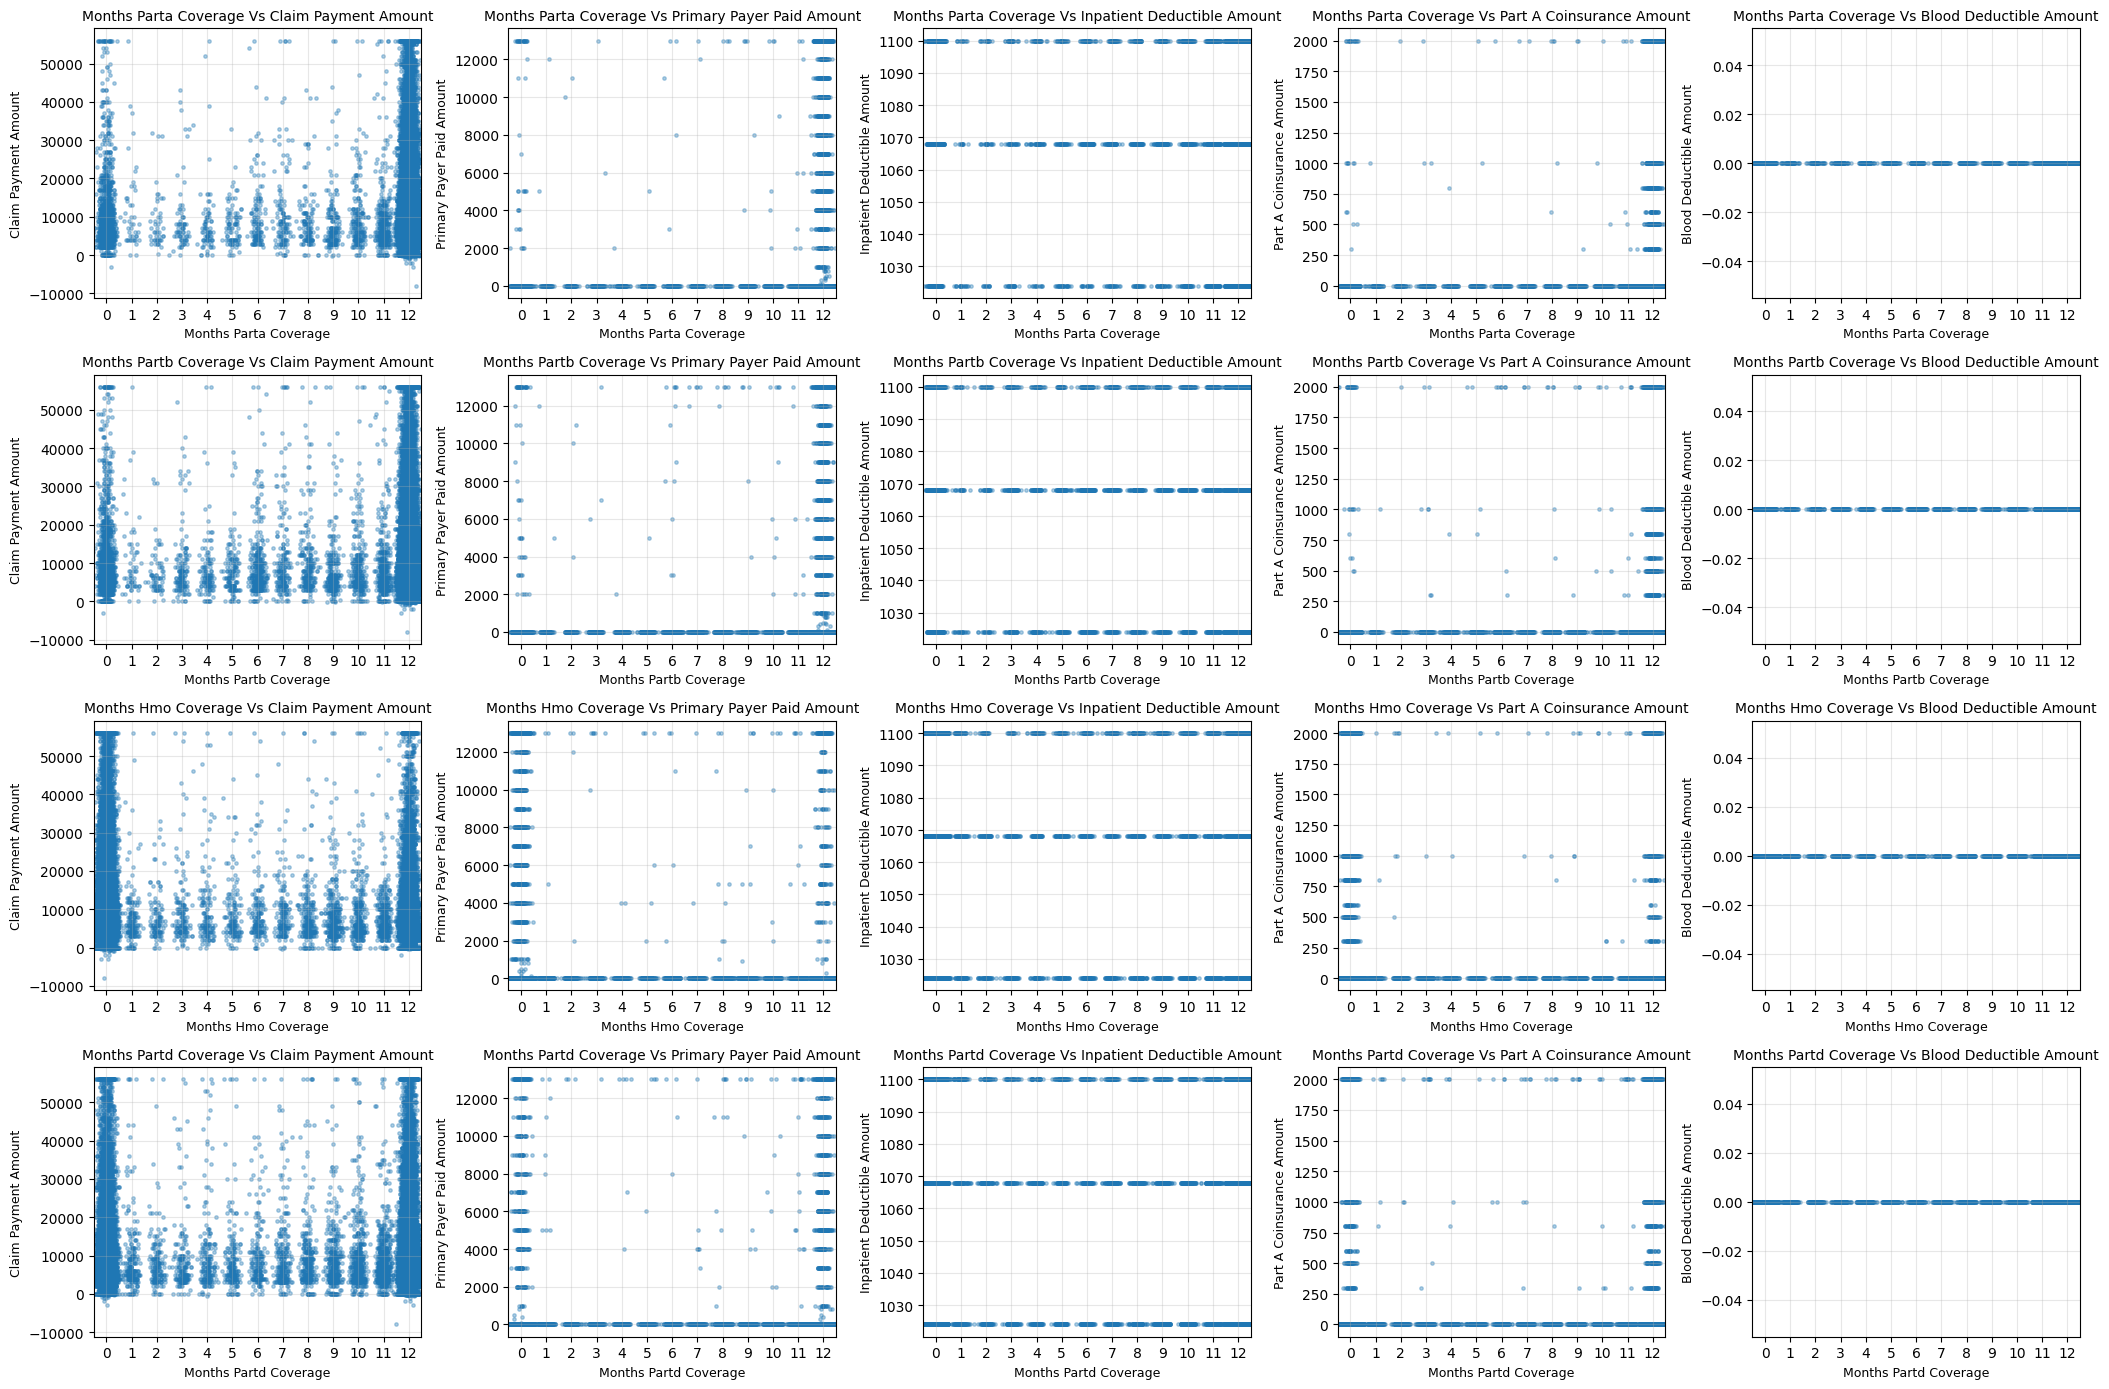

In [30]:
# We want to see all the coverages like part A, part B, HMO, part D is needed in our model or not
# to do that we can to see if they is pattern between those coverage months with the payment variables like
# claim_payment_amount, primary_payer_paid_amount, inpatient_deductible_amount, part_a_coinsurance_amount,blood_deductible_amount

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql.functions import col

coverage_cols = [
    "months_partA_coverage",
    "months_partB_coverage",
    "months_hmo_coverage",
    "months_partD_coverage"
]

payment_cols = [
    "claim_payment_amount",
    "primary_payer_paid_amount",
    "inpatient_deductible_amount",
    "part_a_coinsurance_amount",
    "blood_deductible_amount"
]

# Pull just the needed columns and drop rows that are all-NA on either side
df_small = beneficiary_claim.select(coverage_cols + payment_cols)

# Convert to Pandas
pdf = df_small.toPandas()

# Keep rows where at least one coverage col and one payment col are present
pdf = pdf.dropna(subset=coverage_cols, how="all").dropna(subset=payment_cols, how="all")

# clip extreme outliers on each payment column to the 99th percentile for clearer visuals
clip_pct = 0.99
for y in payment_cols:
    if y in pdf.columns:
        upper = pdf[y].quantile(clip_pct)
        pdf[y] = np.where(pdf[y] > upper, upper, pdf[y])

# Plot grid: rows = coverage vars, cols = payment vars
rows, cols = len(coverage_cols), len(payment_cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols*4.2, rows*3.5), sharex=False, sharey=False)

# Scatter each pair
rng = np.random.default_rng(42)
for i, x in enumerate(coverage_cols):
    # Ensure integer-like months show as discrete values; add tiny jitter to reduce overplotting
    xvals = pdf[x].values

    for j, y in enumerate(payment_cols):
        ax = axes[i, j] if rows > 1 else axes[j]

        # Drop rows with missing x or y for this specific plot
        mask = (~pd.isna(pdf[x])) & (~pd.isna(pdf[y]))
        xv = xvals[mask].astype(float)

        # small jitter for discreteness (±0.15 months)
        jitter = rng.normal(0, 0.15, size=xv.shape[0])
        xv_plot = xv + jitter

        yv = pdf.loc[mask, y].values.astype(float)

        ax.scatter(xv_plot, yv, s=6, alpha=0.35)

        ax.set_title(f"{x} vs {y}".replace("_", " ").title(), fontsize=10)
        ax.set_xlabel(x.replace("_", " ").title(), fontsize=9)
        ax.set_ylabel(y.replace("_", " ").title(), fontsize=9)
        ax.grid(alpha=0.3)

        ax.set_xticks(range(0, 13))
        ax.set_xlim(-0.5, 12.5)

plt.tight_layout()
plt.show()


**Across all four coverage month variables, payment components show no systematic change with months of coverage so its safe to exclude from predictive features.**

In [31]:
#drop "months_partA_coverage","months_partB_coverage","months_hmo_coverage","months_partD_coverage"
beneficiary_claim=beneficiary_claim.drop("months_partA_coverage","months_partB_coverage","months_hmo_coverage","months_partD_coverage")
beneficiary_claim.show(3, truncate=False)

+----------------+---------------+----------------+--------------+---------------+--------------------+-------------------------+-----------------------+-----------------------+-------------------+------------------------+----------------------------+---------------------------+-------------------------+-----------------------+---------------------+--------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+----------+------+---------+---------------------------+-----+------+---------+-------------+----------------------+------+----+----------+--------+----------------------+------------+--------------------+------+-----------+---------+---------+-----------+---------+---------+------------+----------+----------+----------+------+------------+
|beneficiary_id  |claim_id       |claim_start_date

In [32]:
#drop MEDREIMB_IP, BENRES_IP, PPPYMT_IP, MEDREIMB_OP, BENRES_OP, PPPYMT_OP, MEDREIMB_CAR, BENRES_CAR, and PPPYMT_CAR
beneficiary_claim=beneficiary_claim.drop("MEDREIMB_IP","BENRES_IP","PPPYMT_IP, MEDREIMB_OP","BENRES_OP","PPPYMT_OP","MEDREIMB_CAR","BENRES_CAR","PPPYMT_CAR")
beneficiary_claim.show(3, truncate=False)

+----------------+---------------+----------------+--------------+---------------+--------------------+-------------------------+-----------------------+-----------------------+-------------------+------------------------+----------------------------+---------------------------+-------------------------+-----------------------+---------------------+--------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+----------+------+---------+---------------------------+-----+------+---------+-------------+----------------------+------+----+----------+--------+----------------------+------------+--------------------+------+---------+-----------+----------+-----+------------+
|beneficiary_id  |claim_id       |claim_start_date|claim_end_date|provider_number|claim_payment_amount|primary_payer_paid_amount

In this step, we removed the following variables:
MEDREIMB_IP, BENRES_IP, PPPYMT_IP, MEDREIMB_OP, BENRES_OP, PPPYMT_OP, MEDREIMB_CAR, BENRES_CAR, and PPPYMT_CAR.

## Next step is to join DRG tables

These variables **represent annual aggregated payments at the beneficiary level, summing all inpatient, outpatient, or carrier (physician) services during the year.**
Since our project focuses on individual claim-level payment prediction — estimating the expected reimbursement for a specific service or admission — these aggregated fields are **not directly relevant and could introduce data leakage.**
Therefore, they were excluded from the modeling dataset.

We will join the MS-DRG reference tables for 2008, 2009, and 2010 with the beneficiary_claim dataset using the DRG code (drg_cd) as the key.
This integration will allow us to append the corresponding DRG weights and MS-DRG titles to each claim, enabling both the calculation of expected payments and the identification of the clinical diagnosis or case type for every inpatient claim.

**Why this step is important in this project?**



*   DRG Weight → quantifies the relative resource intensity of the case; forms the basis for the “expected payment” regression.
*   MS-DRG Title → makes the data human-readable and supports diagnosis-level EDA (e.g., which DRGs have the highest variance or cost).


*   Year-specific join → ensures correct matching because DRG weights change slightly each fiscal year.









In [33]:
MS_DRG_2008=(spark.read
                 .option("header",True)
                 .option("sep","\t")
                 .option("quote", "\u0000")
                 .csv("/content/drive/MyDrive/Big Data Project/FY 2008 Final Rule Table 5 Final.txt"))
print("Total Rows",MS_DRG_2008.count())
MS_DRG_2008.show(10, truncate=False)

Total Rows 747
+------+------------------------------+-------------------------------+---+----+---------------------------------------------------------------------+--------+------------------+-------------------+
|MS-DRG|FY08 Final Rule Post-Acute DRG|FY08 Final Rule Special Pay DRG|MDC|TYPE|MS-DRG Title                                                         |Weights |Geometric Mean LOS|Arithmetic Mean LOS|
+------+------------------------------+-------------------------------+---+----+---------------------------------------------------------------------+--------+------------------+-------------------+
|001   |No                            |No                             |PRE|SURG|Heart transplant or implant of heart assist system w MCC             |23.1117 |30.8              |45.6               |
|002   |No                            |No                             |PRE|SURG|Heart transplant or implant of heart assist system w/o MCC           |16.2735 |16.1              |22.8       

In [34]:
MS_DRG_2009=(spark.read
                 .option("header",True)
                 .option("inferschema",True)
                 .csv("/content/drive/MyDrive/Big Data Project/FY09_IPPS_ FR_Table_ 5.csv"))

print("Total Rows",MS_DRG_2009.count())
MS_DRG_2009.show(10, truncate=False)

Total Rows 749
+------+------------------------------+-------------------------------+---+----+-------------------------------------------------------------------+-------+------------------+-------------------+
|MS-DRG|FY09 Final Rule Post-Acute DRG|FY09 Final Rule Special Pay DRG|MDC|TYPE|MS-DRG Title                                                       |Weights|Geometric mean LOS|Arithmetic mean LOS|
+------+------------------------------+-------------------------------+---+----+-------------------------------------------------------------------+-------+------------------+-------------------+
|001   |No                            |No                             |PRE|SURG|Heart transplant or implant of heart assist system w MCC           |23.6701|29.6              |41.1               |
|002   |No                            |No                             |PRE|SURG|Heart transplant or implant of heart assist system w/o MCC         |12.8157|18.7              |25.3               |
|003 

In [35]:
MS_DRG_2010=(spark.read
                 .option("header",True)
                 .option("sep","\t")
                 .option("quote", "\u0000")
                 .csv("/content/drive/MyDrive/Big Data Project/FY 2010 FR Table 5.txt"))
print("Total Rows",MS_DRG_2010.count())
MS_DRG_2010.show(10, truncate=False)

Total Rows 748
+-------+---------------------------------+----------------------------------+---+----+---------------------------------------------------------------------+-------+------------------+-------------------+
|MS-DRG |FY 2010 Final Rule Post-Acute DRG|FY 2010 Final Rule Special Pay DRG|MDC|TYPE|MS-DRG Title                                                         |Weights|Geometric mean LOS|Arithmetic mean LOS|
+-------+---------------------------------+----------------------------------+---+----+---------------------------------------------------------------------+-------+------------------+-------------------+
|001    |No                               |No                                |PRE|SURG|HEART TRANSPLANT OR IMPLANT OF HEART ASSIST SYSTEM W MCC             |24.8548|31.5              |43.9               |
|002    |No                               |No                                |PRE|SURG|HEART TRANSPLANT OR IMPLANT OF HEART ASSIST SYSTEM W/O MCC           |11.754 |

# Merge DRG tables of 2008, 2009, 2010

In [36]:
# I want to add one column where each record will be 2008 in MS_DRG_2008
from pyspark.sql.functions import lit
MS_DRG_2008 = MS_DRG_2008.withColumn("year", lit(2008))
MS_DRG_2009 = MS_DRG_2009.withColumn("year", lit(2009))
MS_DRG_2010 = MS_DRG_2010.withColumn("year", lit(2010))

MS_DRG_2008=MS_DRG_2008.drop("FY08 Final Rule Post-Acute DRG","FY08 Final Rule Special Pay DRG")
MS_DRG_2009=MS_DRG_2009.drop("FY09 Final Rule Post-Acute DRG","FY09 Final Rule Special Pay DRG")
MS_DRG_2010=MS_DRG_2010.drop("FY 2010 Final Rule Post-Acute DRG","FY 2010 Final Rule Special Pay DRG")

MS_DRG_2008=(MS_DRG_2008.withColumnRenamed("Weights ","Weights")
              .withColumnRenamed("MS-DRG","MS_DRG")
              .withColumnRenamed("MS-DRG Title","DRG_Title"))

MS_DRG_2009=(MS_DRG_2009.withColumnRenamed("MS-DRG","MS_DRG")
              .withColumnRenamed("MS-DRG Title","DRG_Title"))

MS_DRG_2010=(MS_DRG_2010.withColumnRenamed("MS-DRG ","MS_DRG")
             .withColumnRenamed("MS-DRG Title","DRG_Title"))

MS_DRG_2010.show(3, truncate=False)
MS_DRG_2009.show(3, truncate=False)
MS_DRG_2008.show(3, truncate=False)

+------+---+----+---------------------------------------------------------------------+-------+------------------+-------------------+----+
|MS_DRG|MDC|TYPE|DRG_Title                                                            |Weights|Geometric mean LOS|Arithmetic mean LOS|year|
+------+---+----+---------------------------------------------------------------------+-------+------------------+-------------------+----+
|001   |PRE|SURG|HEART TRANSPLANT OR IMPLANT OF HEART ASSIST SYSTEM W MCC             |24.8548|31.5              |43.9               |2010|
|002   |PRE|SURG|HEART TRANSPLANT OR IMPLANT OF HEART ASSIST SYSTEM W/O MCC           |11.754 |16.4              |21.2               |2010|
|003   |PRE|SURG|"ECMO OR TRACH W MV 96+ HRS OR PDX EXC FACE, MOUTH & NECK W MAJ O.R."|18.2667|31.6              |38.5               |2010|
+------+---+----+---------------------------------------------------------------------+-------+------------------+-------------------+----+
only showing top 3 r

In [37]:
drg_master = MS_DRG_2008.unionByName(MS_DRG_2009).unionByName(MS_DRG_2010)


In [38]:
drg_master.show(10, truncate=False)
print("Total Rows:",drg_master.count())
drg_master.select("year").distinct().show()

+------+---+----+---------------------------------------------------------------------+-------+------------------+-------------------+----+
|MS_DRG|MDC|TYPE|DRG_Title                                                            |Weights|Geometric Mean LOS|Arithmetic Mean LOS|year|
+------+---+----+---------------------------------------------------------------------+-------+------------------+-------------------+----+
|001   |PRE|SURG|Heart transplant or implant of heart assist system w MCC             |23.1117|30.8              |45.6               |2008|
|002   |PRE|SURG|Heart transplant or implant of heart assist system w/o MCC           |16.2735|16.1              |22.8               |2008|
|003   |PRE|SURG|"ECMO or trach w MV 96+ hrs or PDX exc face, mouth & neck w maj O.R."|18.7707|33.4              |40.6               |2008|
|004   |PRE|SURG|"Trach w MV 96+ hrs or PDX exc face, mouth & neck w/o maj O.R."      |11.4219|23.8              |29.3               |2008|
|005   |PRE|SURG|Liv

# Add "Year" column in claim dataset

In [39]:
from pyspark.sql.functions import year

beneficiary_claim = beneficiary_claim.withColumn("year", year(col("claim_end_date")))
beneficiary_claim.show(3, truncate=False)


+----------------+---------------+----------------+--------------+---------------+--------------------+-------------------------+-----------------------+-----------------------+-------------------+------------------------+----------------------------+---------------------------+-------------------------+-----------------------+---------------------+--------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+----------+------+---------+---------------------------+-----+------+---------+-------------+----------------------+------+----+----------+--------+----------------------+------------+--------------------+------+---------+-----------+----------+-----+------------+----+
|beneficiary_id  |claim_id       |claim_start_date|claim_end_date|provider_number|claim_payment_amount|primary_payer_paid_a

In [40]:
# Two key join DRG code and year
beneficiary_claim = beneficiary_claim.join(
    drg_master,
    (beneficiary_claim.drg_code == drg_master.MS_DRG) &
    (beneficiary_claim.year == drg_master.year),
    "left"
)

beneficiary_claim.show(10, truncate=False)

# print total number of rows in beneficiary_claim merged dataset
print("Total Rows:",beneficiary_claim.count())

+----------------+---------------+----------------+--------------+---------------+--------------------+-------------------------+-----------------------+-----------------------+-------------------+------------------------+----------------------------+---------------------------+-------------------------+-----------------------+---------------------+--------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+----------+------+---------+---------------------------+-----+------+---------+-------------+----------------------+------+----+----------+--------+----------------------+------------+--------------------+------+---------+-----------+----------+-----+------------+----+------+----+----+--------------------------------------------------------------------+-------+------------------+-----------

In [41]:
# I want to check if there are any nulls in MS_DRG column
beneficiary_claim.filter(col("MS_DRG").isNull()).show(3,truncate=False)

# print total rows where MS_DRG is null
print("Total Rows where MS_DRG is null:",beneficiary_claim.filter(col("MS_DRG").isNull()).count())

# I want to see the unique drg_code where MS_DRG is NULL
beneficiary_claim.filter(col("MS_DRG").isNull()).select("drg_code").distinct().show()

+----------------+---------------+----------------+--------------+---------------+--------------------+-------------------------+-----------------------+-----------------------+-------------------+------------------------+----------------------------+---------------------------+-------------------------+-----------------------+---------------------+--------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+----------+------+---------+---------------------------+-----+------+---------+-------------+----------------------+------+----+----------+--------+----------------------+------------+--------------------+------+---------+-----------+----------+--------+------------+----+------+----+----+---------+-------+------------------+-------------------+----+
|beneficiary_id  |claim_id       |claim_s

DRG Table Integration (2008–2010)

To ensure each claim in the dataset reflects the appropriate reimbursement logic for its service year, the MS-DRG reference tables for fiscal years 2008, 2009, and 2010 were combined and joined with the main beneficiary_claim dataset.

Each DRG reference file contains year-specific information such as MS-DRG code, DRG title, relative weight, and average length of stay (LOS). **Since DRG weights and definitions change slightly each year, a direct merge using only the DRG code could result in mismatches or duplicate joins.**

To address this, a year-aware integration was implemented:

**A year column was added to each DRG reference table corresponding to its fiscal year (2008, 2009, or 2010).**

**The three DRG tables were combined into a single DRG Master Table using a union operation.**

**The beneficiary_claim dataset was enriched with a year column derived from the claim discharge date (CLM_THRU_DT).**

A two-key join was performed on both CLM_DRG_CD = MS_DRG and year, ensuring each claim was linked to the correct DRG weight and title for that specific year.

This integration allows the project to accurately capture diagnostic and clinical case information, as well as year-specific DRG weights, which are essential for calculating expected payments and analyzing payment variance across different hospital service types and years.

In [42]:
# Remove those 405 rows where we don't have any information about diagnosis realted group as they won't provide use any intelligence
beneficiary_claim = beneficiary_claim.filter(col("MS_DRG").isNotNull())
print("Total Rows:",beneficiary_claim.count())

Total Rows: 65769


In [43]:
beneficiary_claim.show(3, truncate=False)

+----------------+---------------+----------------+--------------+---------------+--------------------+-------------------------+-----------------------+-----------------------+-------------------+------------------------+----------------------------+---------------------------+-------------------------+-----------------------+---------------------+--------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+----------+------+---------+---------------------------+-----+------+---------+-------------+----------------------+------+----+----------+--------+----------------------+------------+--------------------+------+---------+-----------+----------+-----+------------+----+------+---+----+------------------------------------------------------------+-------+------------------+-------------------+

Medicare IPPS, the pass-through payment is separate from the DRG-based claim payment. A claim can have both a DRG payment (claim_payment_amount) and a pass-through per diem amount. pass_through_per_diem_amount is an extra reimbursement per day for special costs. So we will create a new column named **(add_on) by calculating pass_through_per_diem_amount * utilization_day_count.**

In [44]:
#create a new column named add_on by multiplying pass_through_per_diem_amount and utilization_day_count
from pyspark.sql.functions import col

beneficiary_claim = beneficiary_claim.withColumn(
    "add_on",
    col("pass_through_per_diem_amount")*
    col("utilization_day_count")
)

beneficiary_claim.show(3, truncate=False)

+----------------+---------------+----------------+--------------+---------------+--------------------+-------------------------+-----------------------+-----------------------+-------------------+------------------------+----------------------------+---------------------------+-------------------------+-----------------------+---------------------+--------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+----------+------+---------+---------------------------+-----+------+---------+-------------+----------------------+------+----+----------+--------+----------------------+------------+--------------------+------+---------+-----------+----------+-----+------------+----+------+---+----+------------------------------------------------------------+-------+------------------+-------------------+

In [45]:
# show all records where claim_payment_amount, primary_payer_paid_amount, inpatient_deductible_amount, part_a_coinsurance_amount, blood_deductible_amount, add_on are null
from pyspark.sql.functions import col, when, count
cols_to_check = [
    "claim_payment_amount",
    "primary_payer_paid_amount",
    "inpatient_deductible_amount",
    "part_a_coinsurance_amount",
    "blood_deductible_amount",
    "add_on"
]

beneficiary_claim.select([
    count(when(col(c).isNull(), c)).alias(c + "_nulls") for c in cols_to_check
]).show()

+--------------------------+-------------------------------+---------------------------------+-------------------------------+-----------------------------+------------+
|claim_payment_amount_nulls|primary_payer_paid_amount_nulls|inpatient_deductible_amount_nulls|part_a_coinsurance_amount_nulls|blood_deductible_amount_nulls|add_on_nulls|
+--------------------------+-------------------------------+---------------------------------+-------------------------------+-----------------------------+------------+
|                         0|                              0|                             2143|                              0|                            0|           0|
+--------------------------+-------------------------------+---------------------------------+-------------------------------+-----------------------------+------------+



The variable (inpatient_deductible_amount) represents the fixed deductible a patient owes for an inpatient benefit period before Medicare coverage begins.
In cases where this field was null, it likely indicates that the deductible had already been met earlier in the benefit period or was covered by another payer.
Therefore, instead of imputing with the mode, I will replace all NULL with 0 to reflect no deductible applied for that claim.

In [46]:
beneficiary_claim = beneficiary_claim.fillna({"inpatient_deductible_amount": 0})

**Compute total payment received by hospital per claim**

In [47]:
from pyspark.sql.functions import col

beneficiary_claim = beneficiary_claim.withColumn(
    "Total_Payment_received",
    col("claim_payment_amount") +
    col("primary_payer_paid_amount") +
    col("inpatient_deductible_amount") +
    col("part_a_coinsurance_amount") +
    col("blood_deductible_amount") +
    col("add_on")
)

**Compute base rate per claim**

In [48]:
from pyspark.sql.functions import round, col
beneficiary_claim = beneficiary_claim.withColumn(
    "Base_Rate",
    round(col("Total_Payment_received") / col("Weights"),2)
)

In [49]:
beneficiary_claim.show(5, truncate=False)

+----------------+---------------+----------------+--------------+---------------+--------------------+-------------------------+-----------------------+-----------------------+-------------------+------------------------+----------------------------+---------------------------+-------------------------+-----------------------+---------------------+--------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+----------+------+---------+---------------------------+-----+------+---------+-------------+----------------------+------+----+----------+--------+----------------------+------------+--------------------+------+---------+-----------+----------+-----+------------+----+------+----+----+--------------------------------------------------------------------+-------+------------------+-----------

In [50]:
# i want to see the number of NULL in attending_physician_npi, operating_physician_npi and other_physician_npi

beneficiary_claim.select(
    sum(col("attending_physician_npi").isNull().cast("int")).alias("attending_nulls"),
    sum(col("operating_physician_npi").isNull().cast("int")).alias("operating_nulls"),
    sum(col("other_physician_npi").isNull().cast("int")).alias("other_nulls")
).show()


+---------------+---------------+-----------+
|attending_nulls|operating_nulls|other_nulls|
+---------------+---------------+-----------+
|            600|          27263|      58187|
+---------------+---------------+-----------+



In [51]:
# I want total rows where attending_physician_npi, operating_physician_npi, other_physician_npi all are null
beneficiary_claim.filter(col("attending_physician_npi").isNull() &
                        col("operating_physician_npi").isNull() & col("other_physician_npi").isNull()).count()

563

In [52]:
from pyspark.sql.functions import when, col

# Drop records where all NPI columns are NULL
beneficiary_claim = beneficiary_claim.filter(~(
    col("attending_physician_npi").isNull() &
    col("operating_physician_npi").isNull() &
    col("other_physician_npi").isNull()
))

# Convert NPI presence to binary
beneficiary_claim = (beneficiary_claim
    .withColumn("attending_present", when(col("attending_physician_npi").isNotNull(), 1).otherwise(0))
    .withColumn("operating_present", when(col("operating_physician_npi").isNotNull(), 1).otherwise(0))
    .withColumn("other_present", when(col("other_physician_npi").isNotNull(), 1).otherwise(0))
)

# Add total NPI count per claim
beneficiary_claim = beneficiary_claim.withColumn("npi_count",
                           col("attending_present") + col("operating_present") + col("other_present"))
# Drop columns attending_physician_npi, operating_physician_npi, other_physician_npi
beneficiary_claim = beneficiary_claim.drop("attending_physician_npi", "operating_physician_npi","other_physician_npi")

beneficiary_claim.show(3, truncate=False)


+----------------+---------------+----------------+--------------+---------------+--------------------+-------------------------+------------------------+----------------------------+---------------------------+-------------------------+-----------------------+---------------------+--------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+----------+------+---------+---------------------------+-----+------+---------+-------------+----------------------+------+----+----------+--------+----------------------+------------+--------------------+------+---------+-----------+----------+-----+------------+----+------+---+----+------------------------------------------------------------+-------+------------------+-------------------+----+------+----------------------+---------+-----------------+-----

**Handling Physician NPI Variables**

The dataset contains three physician identifier fields — **Attending Physician NPI, Operating Physician NPI, and Other Physician NPI** — representing the unique IDs of providers involved in each inpatient claim. These variables often indicate the complexity of care delivery, as multiple physicians can be involved in a single episode of treatment.

However, 563 records had **all three NPI values missing**, meaning there was no identifiable physician associated with those claims. In a real-world context, such cases typically represent **facility-only or incomplete billing records** (e.g., technical services billed by a hospital rather than a specific doctor). Therefore, these records were removed to maintain data consistency and analytical relevance.

Next, each NPI column was **converted into a binary indicator variable** — assigning 1 if an NPI was present and 0 if missing. This transformation enables the quantification of **provider involvement** without relying on specific physician identifiers, which are anonymized and non-informative in this dataset.

Finally, a derived variable, npi_count, was created by summing the binary indicators. This new feature reflects the **number of distinct physician roles involved per claim**, serving as a proxy for **care complexity**.
This step ensures that provider participation is captured in a meaningful, privacy-preserving, and model-friendly way.

# **Exploratory Data Analysis**

## **We want to know that how does the effective base rate vary across states, and what might that tell us about reimbursement differences or cost structures?**

In [53]:
from pyspark.sql.functions import col, round, avg
import plotly.express as px

state_base_rate = (
    beneficiary_claim
    .groupBy("state_abbr")
    .agg(round(avg(col("Base_Rate")), 2).alias("Avg_Base_Rate"))
    .orderBy(col("Avg_Base_Rate").desc())
)

pdf = state_base_rate.toPandas()
fig = px.choropleth(
    pdf,
    locations="state_abbr",
    locationmode="USA-states",
    color="Avg_Base_Rate",
    color_continuous_scale="Viridis",
    scope="usa",
    title="Average Hospital Base Rate by State"
)
fig.update_layout(width=1000, height=600)
fig.show()


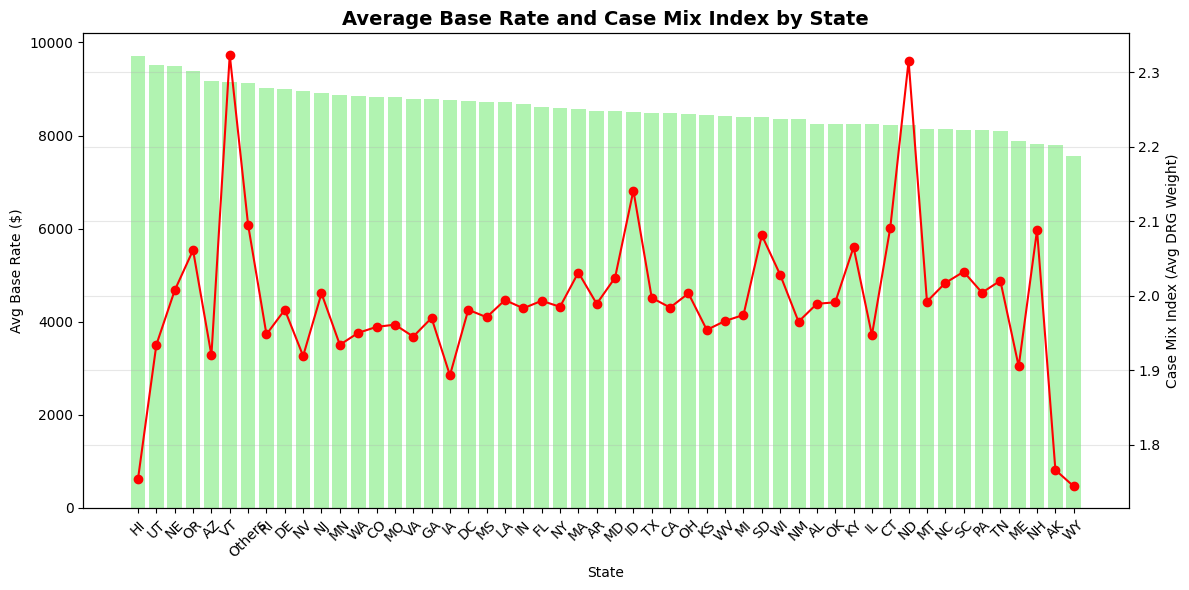

In [54]:
from pyspark.sql.functions import avg, round
from pyspark.sql.functions import col

state_cmi = (
    beneficiary_claim
    .groupBy("state_abbr")
    .agg(round(avg("Weights"), 3).alias("Case_Mix_Index"))
    .orderBy("Case_Mix_Index", ascending=False)
)

state_summary = (
    beneficiary_claim
    .groupBy("state_abbr")
    .agg(
        round(avg(col("Base_Rate")), 2).alias("Avg_Base_Rate"),
        round(avg(col("Weights")), 3).alias("Case_Mix_Index")
    )
    .orderBy("Avg_Base_Rate", ascending=False)
)

pdf = state_summary.toPandas().sort_values(by="Avg_Base_Rate", ascending=False)

fig, ax1 = plt.subplots(figsize=(12,6))
ax2 = ax1.twinx()

ax1.bar(pdf["state_abbr"], pdf["Avg_Base_Rate"], color='lightgreen', alpha=0.7, label="Avg Base Rate ($)")
ax2.plot(pdf["state_abbr"], pdf["Case_Mix_Index"], color='red', marker='o', label="Case Mix Index")

ax1.set_xlabel("State")
ax1.set_ylabel("Avg Base Rate ($)")
ax2.set_ylabel("Case Mix Index (Avg DRG Weight)")
plt.title("Average Base Rate and Case Mix Index by State", fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


The first chart shows that some states like **Hawaii, Nebraska, and Utah have higher hospital payment rates** compared to other states. This is often because Medicare gives extra money to hospitals in places where it’s expensive to operate or difficult to get staff (such as isolated or high-cost areas).

However, this first view doesn’t tell the whole story.

When we add the **Case Mix Index (CMI)** in the second chart which shows how severe or complex the patients’ conditions are we notice something important:


*   **High payments don’t always mean hospitals treat more complex patients.**

*   For example, **Vermont has very complex patients (high CMI) but only average payment rates.**


*   On the other hand, Hawaii still gets high payments even though its patient complexity is low.


This shows that **hospital payments aren’t only based on patient severity**, but also on other factors like:

Location (cost of living, isolation) and other factors that we will find later on.



## **Impact of Number of Physician NPIs on Average Claim Payment**
### Hypothesis: Greater physician involvement (more NPIs per claim) leads to higher total payment due to increased treatment complexity.

In [55]:
from pyspark.sql.functions import col, round, avg, count, when

# Create NPI group label
beneficiary_claim = beneficiary_claim.withColumn(
    "NPI_Group",
    when((col("attending_present")==1) & (col("operating_present")==0) & (col("other_present")==0), "Attending only")
    .when((col("attending_present")==0) & (col("operating_present")==1) & (col("other_present")==0), "Operating only")
    .when((col("attending_present")==0) & (col("operating_present")==0) & (col("other_present")==1), "Other only")
    .when((col("attending_present")==1) & (col("operating_present")==1) & (col("other_present")==0), "Attending + Operating")
    .when((col("attending_present")==1) & (col("operating_present")==1) & (col("other_present")==1), "Attending + Operating + Other")
    .when((col("attending_present")==1) & (col("operating_present")==0) & (col("other_present")==1), "Attending + Other")
    .when((col("attending_present")==0) & (col("operating_present")==1) & (col("other_present")==1), "Operating + Other")
)

# Aggregate average payment and count
npi_payment = (
    beneficiary_claim
    .groupBy("NPI_Group")
    .agg(
        round(avg(col("Total_Payment_received")), 2).alias("Avg_Total_Payment"),
        count("*").alias("Claim_Count")
    )
    .orderBy(col("Avg_Total_Payment"))
)
npi_payment.show(truncate=False)


+-----------------------------+-----------------+-----------+
|NPI_Group                    |Avg_Total_Payment|Claim_Count|
+-----------------------------+-----------------+-----------+
|Other only                   |5024.0           |4          |
|Attending only               |7712.71          |24656      |
|Operating + Other            |7828.0           |5          |
|Attending + Other            |8694.5           |2040       |
|Operating only               |11481.14         |28         |
|Attending + Operating        |13542.14         |32940      |
|Attending + Operating + Other|14715.96         |5533       |
+-----------------------------+-----------------+-----------+



In [56]:
# Remove unwanted categories whose count in the claim data set is extremely low
beneficiary_claim = beneficiary_claim.filter(
    ~(
        ((col("attending_present") == 0) & (col("operating_present") == 0) & (col("other_present") == 1)) |
        ((col("attending_present") == 0) & (col("operating_present") == 1) & (col("other_present") == 0)) |
        ((col("attending_present") == 0) & (col("operating_present") == 1) & (col("other_present") == 1))
    )
)

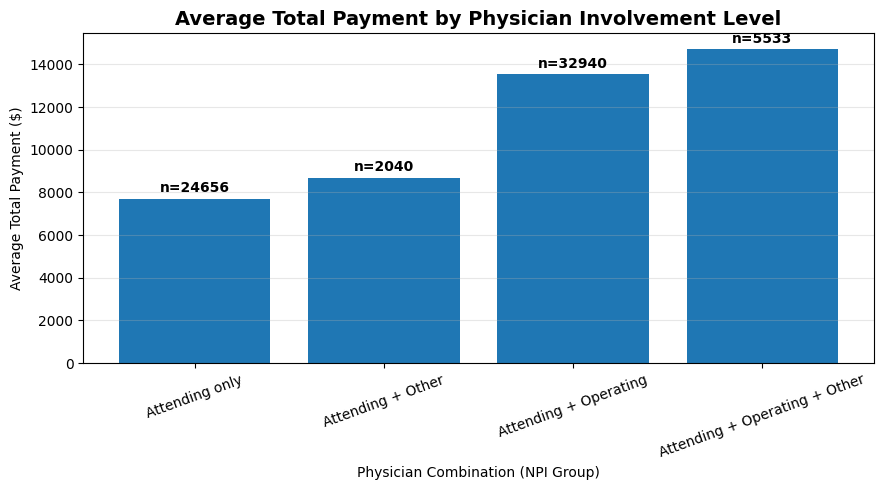

In [57]:
beneficiary_claim = beneficiary_claim.withColumn(
    "NPI_Group",
    when((col("attending_present") == 1) & (col("operating_present") == 0) & (col("other_present") == 0), "Attending only")
    .when((col("attending_present") == 1) & (col("operating_present") == 1) & (col("other_present") == 0), "Attending + Operating")
    .when((col("attending_present") == 1) & (col("operating_present") == 0) & (col("other_present") == 1), "Attending + Other")
    .when((col("attending_present") == 1) & (col("operating_present") == 1) & (col("other_present") == 1), "Attending + Operating + Other")
)

# Aggregate average payment and claim count
npi_payment = (
    beneficiary_claim
    .groupBy("NPI_Group")
    .agg(
        round(avg(col("Total_Payment_received")), 2).alias("Avg_Total_Payment"),
        count("*").alias("Claim_Count")
    )
    .orderBy(col("Avg_Total_Payment"))
)

pdf = npi_payment.toPandas()

# Plot bar chart
plt.figure(figsize=(9,5))
bars = plt.bar(pdf["NPI_Group"], pdf["Avg_Total_Payment"])
plt.title("Average Total Payment by Physician Involvement Level", fontsize=14, fontweight='bold')
plt.xlabel("Physician Combination (NPI Group)")
plt.ylabel("Average Total Payment ($)")
plt.xticks(rotation=20)
plt.grid(alpha=0.3, axis='y')

# Add count labels above bars
for i, (count_val, avg_val) in enumerate(zip(pdf["Claim_Count"], pdf["Avg_Total_Payment"])):
    plt.text(i, avg_val + 300, f'n={count_val}', ha='center', fontsize=10, color='black', fontweight='semibold')

plt.tight_layout()
plt.show()

The visualization confirms that claim costs generally **rise with the number of physicians involved.**
Claims handled by only an attending physician show the lowest average payment, while those involving both attending and operating physicians show a significant increase.
The **highest costs are observed when all three NPIs like attending, operating, and other are present**, suggesting that multi-physician involvement is a strong indicator of clinical complexity and higher resource utilization.

## **How Case Complexity and Length of Stay Drive Hospital Payments Across Major Diagnostic Categories (MDC)**

In [58]:
beneficiary_claim.show(10, truncate=False)

+----------------+---------------+----------------+--------------+---------------+--------------------+-------------------------+------------------------+----------------------------+---------------------------+-------------------------+-----------------------+---------------------+--------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+----------+------+---------+---------------------------+-----+------+---------+-------------+----------------------+------+----+----------+--------+----------------------+------------+--------------------+------+---------+-----------+----------+-----+------------+----+------+----+----+--------------------------------------------------------------------+-------+------------------+-------------------+----+------+----------------------+---------+--------------

In [59]:
# unique MDC
beneficiary_claim.select("MDC").distinct().show(50,truncate=False)
beneficiary_claim.filter(col("MDC").isNull()).count()

+----+
|MDC |
+----+
|07  |
|11  |
|01  |
|22  |
|16  |
|18  |
|17  |
|09  |
|05  |
|19  |
|23  |
|08  |
|03  |
|25  |
|02  |
|06  |
|24  |
|20  |
|10  |
|12  |
|04  |
|13  |
|21  |
|14  |
|PRE |
|NULL|
+----+



368

In [60]:
mdc_mapping = {
    "01": "DISEASES & DISORDERS OF THE NERVOUS SYSTEM",
    "02": "DISEASES & DISORDERS OF THE EYE",
    "03": "DISEASES & DISORDERS OF THE EAR, NOSE, MOUTH & THROAT",
    "04": "DISEASES & DISORDERS OF THE RESPIRATORY SYSTEM",
    "05": "DISEASES & DISORDERS OF THE CIRCULATORY SYSTEM",
    "06": "DISEASES & DISORDERS OF THE DIGESTIVE SYSTEM",
    "07": "DISEASES & DISORDERS OF THE HEPATOBILIARY SYSTEM & PANCREAS",
    "08": "DISEASES & DISORDERS OF THE MUSCULOSKELETAL SYSTEM & CONNECTIVE TISSUE",
    "09": "DISEASES & DISORDERS OF THE SKIN, SUBCUTANEOUS TISSUE & BREAST",
    "10": "ENDOCRINE, NUTRITIONAL & METABOLIC DISEASES & DISORDERS",
    "11": "DISEASES & DISORDERS OF THE KIDNEY & URINARY TRACT",
    "12": "DISEASES & DISORDERS OF THE MALE REPRODUCTIVE SYSTEM",
    "13": "DISEASES & DISORDERS OF THE FEMALE REPRODUCTIVE SYSTEM",
    "14": "PREGNANCY, CHILDBIRTH & THE PUERPERIUM",
    "15": "NEWBORNS & OTHER NEONATES WITH CONDN ORIG IN PERINATAL PERIOD",
    "16": "DISEASES & DISORDERS OF BLOOD, BLOOD FORMING ORGANS, IMMUNOLOGIC DISORDERS",
    "17": "MYELOPROLIFERATIVE DISEASES & DISORDERS, POORLY DIFFERENTIATED NEOPLASM",
    "18": "INFECTIOUS & PARASITIC DISEASES, SYSTEMIC OR UNSPECIFIED SITES",
    "19": "MENTAL DISEASES & DISORDERS",
    "20": "ALCOHOL/DRUG USE & ALCOHOL/DRUG INDUCED ORGANIC MENTAL DISORDERS",
    "21": "INJURIES, POISONINGS & TOXIC EFFECTS OF DRUGS",
    "22": "BURNS",
    "23": "FACTORS INFLUENCING HEALTH STATUS & OTHER CONTACTS WITH HEALTH SERVICES",
    "24": "MULTIPLE SIGNIFICANT TRAUMA",
    "25": "HUMAN IMMUNODEFICIENCY VIRUS INFECTIONS",
    "PRE": "PRE-MDC not assigned based on diagnosis",
    "NULL": "Unknown"
}


In [61]:
from pyspark.sql.functions import udf, col
from pyspark.sql.types import StringType

# Define UDF
def map_mdc(code):
    if code is None:
        return "Unknown"
    return mdc_mapping.get(str(code).zfill(2), "Unknown")

map_mdc_udf = udf(map_mdc, StringType())

# Apply to DataFrame
beneficiary_claim = beneficiary_claim.withColumn("MDC_Label", map_mdc_udf(col("MDC")))

# Preview result
beneficiary_claim.select("MDC", "MDC_Label").distinct().show(50, truncate=False)


+----+--------------------------------------------------------------------------+
|MDC |MDC_Label                                                                 |
+----+--------------------------------------------------------------------------+
|24  |MULTIPLE SIGNIFICANT TRAUMA                                               |
|17  |MYELOPROLIFERATIVE DISEASES & DISORDERS, POORLY DIFFERENTIATED NEOPLASM   |
|14  |PREGNANCY, CHILDBIRTH & THE PUERPERIUM                                    |
|09  |DISEASES & DISORDERS OF THE SKIN, SUBCUTANEOUS TISSUE & BREAST            |
|18  |INFECTIOUS & PARASITIC DISEASES, SYSTEMIC OR UNSPECIFIED SITES            |
|08  |DISEASES & DISORDERS OF THE MUSCULOSKELETAL SYSTEM & CONNECTIVE TISSUE    |
|20  |ALCOHOL/DRUG USE & ALCOHOL/DRUG INDUCED ORGANIC MENTAL DISORDERS          |
|03  |DISEASES & DISORDERS OF THE EAR, NOSE, MOUTH & THROAT                     |
|13  |DISEASES & DISORDERS OF THE FEMALE REPRODUCTIVE SYSTEM                    |
|01  |DISEASES &

In [62]:
beneficiary_claim = beneficiary_claim.withColumn("MDC", col("MDC_Label"))
beneficiary_claim = beneficiary_claim.drop("MDC_Label")
beneficiary_claim.show(5,truncate=False)

+----------------+---------------+----------------+--------------+---------------+--------------------+-------------------------+------------------------+----------------------------+---------------------------+-------------------------+-----------------------+---------------------+--------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+----------+------+---------+---------------------------+-----+------+---------+-------------+----------------------+------+----+----------+--------+----------------------+------------+--------------------+------+---------+-----------+----------+-----+------------+----+------+------------------------------------------------------+----+--------------------------------------------------------------------+-------+------------------+-------------------+----+----

In [63]:
from pyspark.sql.functions import avg
from pyspark.sql.functions import desc
mdc_summary_df= beneficiary_claim.groupBy("MDC").agg(
    avg("Weights").alias("Avg_Weight"),
    avg("utilization_day_count").alias("Avg_LOS"),
    avg("Total_Payment_received").alias("Avg_Payment")
).orderBy(desc("Avg_Weight"))

mdc_summary_df.show(5,truncate=False)

+----------------------------------------------+------------------+------------------+------------------+
|MDC                                           |Avg_Weight        |Avg_LOS           |Avg_Payment       |
+----------------------------------------------+------------------+------------------+------------------+
|PRE-MDC not assigned based on diagnosis       |9.174269675090255 |25.703971119133573|56291.71841155235 |
|MULTIPLE SIGNIFICANT TRAUMA                   |3.47913918918919  |7.202702702702703 |24001.162162162163|
|BURNS                                         |3.2972947368421055|10.052631578947368|36065.26315789474 |
|DISEASES & DISORDERS OF THE CIRCULATORY SYSTEM|2.890660811823202 |4.422393243887489 |11960.602329224273|
|Unknown                                       |2.3515147398843923|10.755434782608695|25392.255434782608|
+----------------------------------------------+------------------+------------------+------------------+
only showing top 5 rows



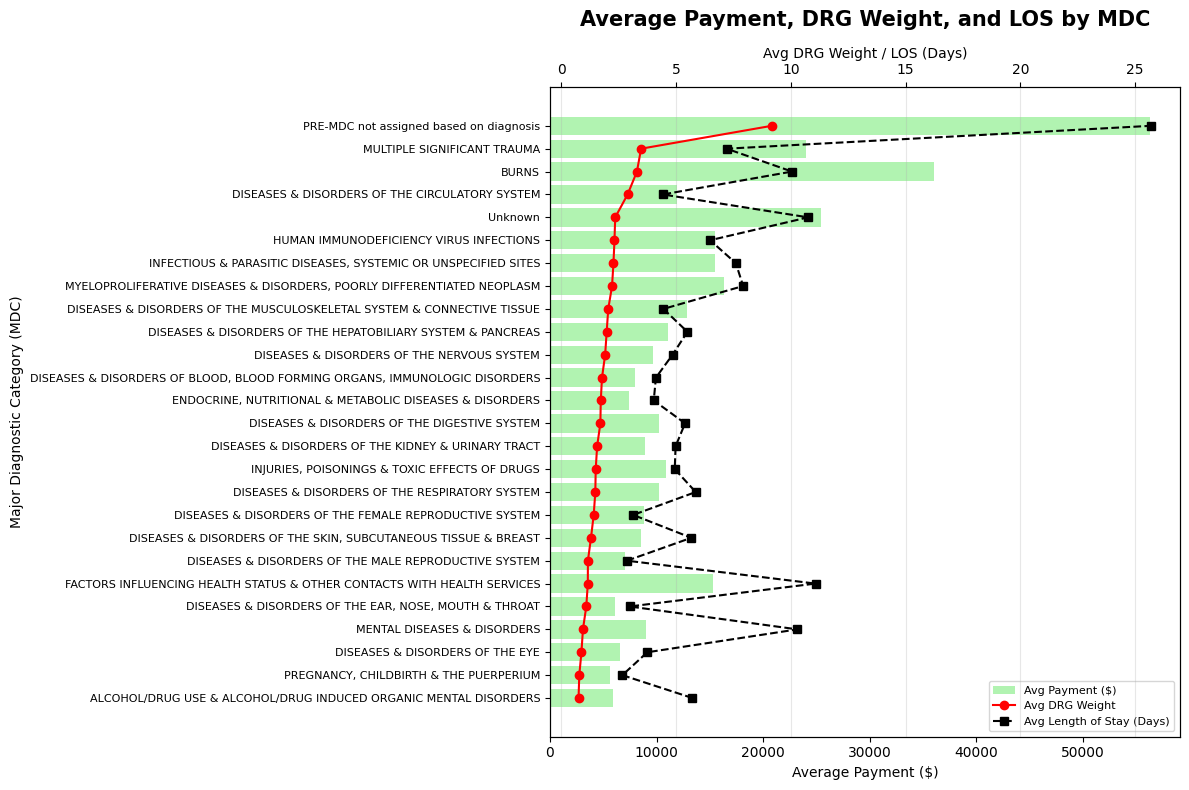

In [64]:
import matplotlib.pyplot as plt
import pandas as pd

pdf = mdc_summary_df.toPandas().sort_values("Avg_Weight", ascending=True)

fig, ax1 = plt.subplots(figsize=(12,8))

# Bar chart for Avg Payment
ax1.barh(pdf["MDC"], pdf["Avg_Payment"], color="lightgreen", alpha=0.7, label="Avg Payment ($)")
ax1.set_xlabel("Average Payment ($)")
ax1.set_ylabel("Major Diagnostic Category (MDC)")
ax1.tick_params(axis='y', labelsize=8)

# First line for Avg DRG Weight
ax2 = ax1.twiny()
ax2.plot(pdf["Avg_Weight"], pdf["MDC"], color="red", marker='o', label="Avg DRG Weight")

# Second line for Avg LOS (using same x-axis scale as DRG Weight)
ax2.plot(pdf["Avg_LOS"], pdf["MDC"], color="black", marker='s', linestyle='--', label="Avg Length of Stay (Days)")

# Labels and title
plt.title("Average Payment, DRG Weight, and LOS by MDC", fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel("Average Payment ($)")
ax2.set_xlabel("Avg DRG Weight / LOS (Days)")

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="lower right", fontsize=8)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


This chart compares Average Payment, Average DRG Weight (which represents case complexity), and Average Length of Stay (LOS) for each Major Diagnostic Category (MDC).

It helps us understand how the **clinical complexity and hospital stay duration influence the Medicare payments hospitals receive**.
Each bar shows the average payment per claim, while the two lines show how complexity (red) and length of stay (black) vary across different diagnoses.

Key Insights

**Strong relationship between complexity and payment**
As expected, categories with higher DRG weights, such as Multiple Significant Trauma and Burns,  have significantly higher average payments, showing that hospitals are reimbursed more for treating severe and resource-intensive cases.

**High cost, moderate stay categories**
Some MDCs like Burns and Major Circulatory System Disorders have high payments despite moderate LOS, suggesting these treatments involve specialized care, expensive equipment, or surgical procedures rather than long hospitalization.

**Low complexity but longer stays**
On the other hand, conditions like Mental Health Disorders or Reproductive System Diseases show longer stays but lower payments, which may reflect lower-cost but prolonged care, possibly due to patient monitoring or non-surgical treatment.

**Operational relevance**
For hospital administrators, this helps identify service lines that generate high costs but may not yield proportionate reimbursements — useful for negotiation and efficiency planning.
For example, Infectious Diseases or Myeloproliferative diseases have moderate weights but relatively high LOS, signaling potential opportunities for length-of-stay reduction or process optimization.

# **Feature Engineering**
Encoding categorical variables (e.g., one-hot, label encoding)

Feature scaling (normalization or standardization)

Creating new features (e.g., ratios, date differences, interaction terms)

Handling class imbalance (oversampling/undersampling)

Dimensionality reduction (PCA, feature selection)

In [65]:
beneficiary_claim.show(5)

+----------------+---------------+----------------+--------------+---------------+--------------------+-------------------------+------------------------+----------------------------+---------------------------+-------------------------+-----------------------+---------------------+--------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+----------+------+---------+---------------------------+-----+------+---------+-------------+----------------------+------+----+----------+--------+----------------------+------------+--------------------+------+---------+-----------+----------+-----+------------+----+------+--------------------+----+--------------------+-------+------------------+-------------------+----+------+----------------------+---------+-----------------+-----------------+----------

In [66]:
# I want to count the unique values in admitting_diagnosis_code
cols = ["ICD9_DGNS_CD_1","ICD9_DGNS_CD_2","ICD9_DGNS_CD_3","ICD9_DGNS_CD_4","ICD9_DGNS_CD_5","ICD9_DGNS_CD_6","ICD9_DGNS_CD_7","ICD9_DGNS_CD_8",
        "ICD9_DGNS_CD_9","ICD9_DGNS_CD_10","ICD9_PRCDR_CD_1","ICD9_PRCDR_CD_2","ICD9_PRCDR_CD_3","ICD9_PRCDR_CD_4","ICD9_PRCDR_CD_5","ICD9_PRCDR_CD_6"]

for c in cols:
    distinct_count = beneficiary_claim.select(c).distinct().count()
    print(f"Distinct values in {c}: {distinct_count}")

#count null in for all columns in cols
for c in cols:
    null_count = beneficiary_claim.filter(col(c).isNull()).count()
    print(f"Null values in {c}: {null_count}")

Distinct values in ICD9_DGNS_CD_1: 2701
Distinct values in ICD9_DGNS_CD_2: 2938
Distinct values in ICD9_DGNS_CD_3: 2878
Distinct values in ICD9_DGNS_CD_4: 2878
Distinct values in ICD9_DGNS_CD_5: 2894
Distinct values in ICD9_DGNS_CD_6: 2821
Distinct values in ICD9_DGNS_CD_7: 2798
Distinct values in ICD9_DGNS_CD_8: 2675
Distinct values in ICD9_DGNS_CD_9: 2554
Distinct values in ICD9_DGNS_CD_10: 1119
Distinct values in ICD9_PRCDR_CD_1: 1268
Distinct values in ICD9_PRCDR_CD_2: 1972
Distinct values in ICD9_PRCDR_CD_3: 1657
Distinct values in ICD9_PRCDR_CD_4: 1350
Distinct values in ICD9_PRCDR_CD_5: 1111
Distinct values in ICD9_PRCDR_CD_6: 917
Null values in ICD9_DGNS_CD_1: 20
Null values in ICD9_DGNS_CD_2: 431
Null values in ICD9_DGNS_CD_3: 1161
Null values in ICD9_DGNS_CD_4: 2609
Null values in ICD9_DGNS_CD_5: 4907
Null values in ICD9_DGNS_CD_6: 8087
Null values in ICD9_DGNS_CD_7: 11947
Null values in ICD9_DGNS_CD_8: 16297
Null values in ICD9_DGNS_CD_9: 21098
Null values in ICD9_DGNS_CD_10

**Prepairing diagnosis, attending and procedure codes for model**

In [67]:
#setup column list
from pyspark.sql import functions as F

diagnosis_col = [f"ICD9_DGNS_CD_{i}" for i in range(1, 11)]
procedure_col = [f"ICD9_PRCDR_CD_{i}" for i in range(1, 7)]
admitting_col = "admitting_diagnosis_code"
all_ICD_cols = [admitting_col] + diagnosis_col + procedure_col


In [68]:
#normalize ICD codes, keep letters, remove dots/spaces, uppercase
def normalize_icd_col(df, colname):
    return df.withColumn(
        colname,
        F.when(F.col(colname).isNull(), F.lit(None))
         .otherwise(
            F.upper(
              F.regexp_replace(F.trim(F.col(colname).cast("string")), r"\.", "")
            )
         )
    )

for c in all_ICD_cols:
    beneficiary_claim = normalize_icd_col(beneficiary_claim, c)


In [69]:
# build arrays
beneficiary_claim = (
    beneficiary_claim
      .withColumn("dx_all", F.array(*[F.col(c) for c in diagnosis_col]))
      .withColumn("pr_all", F.array(*[F.col(c) for c in procedure_col]))
      .withColumn("num_dx", F.size(F.expr("filter(dx_all, x -> x is not null)")))
      .withColumn("num_pr", F.size(F.expr("filter(pr_all, x -> x is not null)")))
)

In [70]:
# make columns like principal diagnosis, secondary diagnosis and indicator of has V or E
from pyspark.sql import functions as F

beneficiary_claim = (
    beneficiary_claim
      .withColumn("DX1", F.col("ICD9_DGNS_CD_1"))
      .withColumn("has_secondary_dx", F.when(F.col("num_dx") > 1, 1).otherwise(0))
      # at least one dx starts with 'V'
      .withColumn(
          "has_V_dx",
          (F.size(F.expr("filter(coalesce(dx_all, array()), x -> x like 'V%')")) > 0).cast("int")
      )
      # at least one dx starts with 'E'
      .withColumn(
          "has_E_dx",
          (F.size(F.expr("filter(coalesce(dx_all, array()), x -> x like 'E%')")) > 0).cast("int")
      )
)


In [71]:
#dealing with high cardinality

K = 200
dx1_freqs = (beneficiary_claim
             .groupBy("DX1")
             .count()
             .orderBy(F.desc("count"))
             .limit(K))

top_dx1 = [r["DX1"] for r in dx1_freqs.collect()]

beneficiary_claim = beneficiary_claim.withColumn(
    "DX1_top",
    F.when(F.col("DX1").isin(top_dx1), F.col("DX1")).otherwise(F.lit("OTHER"))
)

In [72]:
# Remove duplicate columns
from pyspark.sql import functions as F
from collections import OrderedDict

df = beneficiary_claim
orig_cols = df.columns
tmp_cols  = [f"{c}___{i}" for i, c in enumerate(orig_cols)]
df = df.toDF(*tmp_cols)

keep_map = OrderedDict()
for i, base in enumerate(orig_cols):
    if base not in keep_map:
        keep_map[base] = tmp_cols[i]

beneficiary_claim = df.select([F.col(tmp).alias(base) for base, tmp in keep_map.items()])

print(beneficiary_claim.columns)


['beneficiary_id', 'claim_id', 'claim_start_date', 'claim_end_date', 'provider_number', 'claim_payment_amount', 'primary_payer_paid_amount', 'admitting_diagnosis_code', 'pass_through_per_diem_amount', 'inpatient_deductible_amount', 'part_a_coinsurance_amount', 'blood_deductible_amount', 'utilization_day_count', 'drg_code', 'ICD9_DGNS_CD_1', 'ICD9_DGNS_CD_2', 'ICD9_DGNS_CD_3', 'ICD9_DGNS_CD_4', 'ICD9_DGNS_CD_5', 'ICD9_DGNS_CD_6', 'ICD9_DGNS_CD_7', 'ICD9_DGNS_CD_8', 'ICD9_DGNS_CD_9', 'ICD9_DGNS_CD_10', 'ICD9_PRCDR_CD_1', 'ICD9_PRCDR_CD_2', 'ICD9_PRCDR_CD_3', 'ICD9_PRCDR_CD_4', 'ICD9_PRCDR_CD_5', 'ICD9_PRCDR_CD_6', 'birth_date', 'gender', 'race_code', 'endstage_renal_disease_indi', 'state', 'county', 'alzheimer', 'heart_failure', 'chronic_kidney_disease', 'cancer', 'COPD', 'depression', 'diabetes', 'ischemic_heart_disease', 'osteoporosis', 'rheumatoid_arthritis', 'stroke', 'PPPYMT_IP', 'MEDREIMB_OP', 'state_abbr', 'race', 'benef_gender', 'year', 'MS_DRG', 'MDC', 'TYPE', 'DRG_Title', 'Weig

In [73]:
# adding a age column at the time of claim
from pyspark.sql import functions as F

beneficiary_claim = beneficiary_claim.withColumn(
    "age_at_claim",
    (F.col("year") - F.year(F.col("birth_date"))).cast("int")
)



In [74]:
beneficiary_claim.show(5)

+----------------+---------------+----------------+--------------+---------------+--------------------+-------------------------+------------------------+----------------------------+---------------------------+-------------------------+-----------------------+---------------------+--------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+----------+------+---------+---------------------------+-----+------+---------+-------------+----------------------+------+----+----------+--------+----------------------+------------+--------------------+------+---------+-----------+----------+-----+------------+----+------+--------------------+----+--------------------+-------+------------------+-------------------+------+----------------------+---------+-----------------+-----------------+-------------+-

In [75]:
from pyspark.sql.functions import col, substring, count

# Extract the 3rd character from provider_number
beneficiary_claim = beneficiary_claim.withColumn("third_char", substring(col("provider_number"), 3, 1))

# Group by the 3rd character and count number of records for each
third_char_counts = (
    beneficiary_claim.groupBy("third_char")
    .agg(count("*").alias("record_count"))
    .orderBy(col("record_count").desc())
)
third_char_counts.show(8)

+----------+------------+
|third_char|record_count|
+----------+------------+
|         0|       56906|
|         T|        2181|
|         S|        1765|
|         1|        1548|
|         3|        1514|
|         2|         706|
|         4|         250|
|         U|          45|
+----------+------------+
only showing top 8 rows



In [76]:
beneficiary_claim = beneficiary_claim.withColumn(
    "endstage_renal_disease_indi",
    F.when(F.col("endstage_renal_disease_indi") == 0, "N").otherwise("Y")
)

In [77]:
beneficiary_claim = beneficiary_claim.withColumn(
    "gender",
    F.when(F.col("gender") == 1, "M").otherwise("F")
)

In [78]:
beneficiary_claim.select("has_V_dx").distinct().show()

+--------+
|has_V_dx|
+--------+
|       1|
|       0|
+--------+



In [79]:
beneficiary_claim.show(3)

+----------------+---------------+----------------+--------------+---------------+--------------------+-------------------------+------------------------+----------------------------+---------------------------+-------------------------+-----------------------+---------------------+--------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+----------+------+---------+---------------------------+-----+------+---------+-------------+----------------------+------+----+----------+--------+----------------------+------------+--------------------+------+---------+-----------+----------+-----+------------+----+------+--------------------+----+--------------------+-------+------------------+-------------------+------+----------------------+---------+-----------------+-----------------+-------------+-

In [80]:
from pyspark.ml.feature import CountVectorizer
from pyspark.ml import Pipeline

# Vectorize diagnosis and procedure arrays
dx_cv = CountVectorizer(
    inputCol="dx_all",
    outputCol="dx_vec",
    vocabSize=1500,
    minDF=20,
    binary=True
)

pr_cv = CountVectorizer(
    inputCol="pr_all",
    outputCol="pr_vec",
    vocabSize=600,
    minDF=10,
    binary=True
)

# Build and apply pipeline
pipe = Pipeline(stages=[dx_cv, pr_cv])
beneficiary_claim = pipe.fit(beneficiary_claim).transform(beneficiary_claim)

# Check results
beneficiary_claim.select("dx_vec", "pr_vec").show(2, truncate=False)


+--------------------------------------------------------------------------------+---------------+
|dx_vec                                                                          |pr_vec         |
+--------------------------------------------------------------------------------+---------------+
|(1500,[0,1,5,20,29,58,66,115,199],[1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0])        |(600,[0],[1.0])|
|(1500,[0,1,3,11,19,25,69,201,210,422],[1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0])|(600,[0],[1.0])|
+--------------------------------------------------------------------------------+---------------+
only showing top 2 rows



In [81]:
# I want to collect all the important features in different categories like categorical, numerical and binary in one data frame seprate from main data set beneficiary_claim
target = ["Total_Payment_received"]

num_features = ["utilization_day_count","Weights","Geometric Mean LOS","npi_count","num_dx","num_pr","age_at_claim"]

cat_features = ["gender","endstage_renal_disease_indi","state_abbr","MS_DRG","MDC","TYPE","NPI_Group",
                "DX1_top"]

binary_features = ["alzheimer","heart_failure","chronic_kidney_disease","cancer","COPD","depression","diabetes","ischemic_heart_disease",
                   "osteoporosis","rheumatoid_arthritis","stroke","has_secondary_dx","has_V_dx","has_E_dx"]

ICD_features = ["dx_vec","pr_vec"]

In [82]:
#Check data types of all features
for col_name, dtype in beneficiary_claim.dtypes:
    if col_name in num_features + cat_features + binary_features + target + ICD_features :
        print(f"{col_name:<35} {dtype}")

utilization_day_count               int
gender                              string
endstage_renal_disease_indi         string
alzheimer                           int
heart_failure                       int
chronic_kidney_disease              int
cancer                              int
COPD                                int
depression                          int
diabetes                            int
ischemic_heart_disease              int
osteoporosis                        int
rheumatoid_arthritis                int
stroke                              int
state_abbr                          string
MS_DRG                              string
MDC                                 string
TYPE                                string
Weights                             string
Geometric Mean LOS                  string
Total_Payment_received              double
npi_count                           int
NPI_Group                           string
num_dx                              int
num_pr    

In [83]:
# COnvert data type for weights and GM lOS features
beneficiary_claim = (
    beneficiary_claim
      .withColumn("Weights", F.col("Weights").cast("double"))
      .withColumn("Geometric Mean LOS", F.col("Geometric Mean LOS").cast("double"))
)

In [84]:
# Drop null
beneficiary_claim = beneficiary_claim.dropna(
    subset=["Weights", "Geometric Mean LOS"]
)

In [85]:
# CHeck null values
from pyspark.sql import functions as F
(
    beneficiary_claim.select([
        F.count(F.when(F.col(c).isNull(), c)).alias(c)
        for c in num_features + cat_features + binary_features + target
        if c in beneficiary_claim.columns
    ])
).show(vertical=True)

-RECORD 0--------------------------
 utilization_day_count       | 0   
 Weights                     | 0   
 Geometric Mean LOS          | 0   
 npi_count                   | 0   
 num_dx                      | 0   
 num_pr                      | 0   
 age_at_claim                | 0   
 gender                      | 0   
 endstage_renal_disease_indi | 0   
 state_abbr                  | 0   
 MS_DRG                      | 0   
 MDC                         | 0   
 TYPE                        | 0   
 NPI_Group                   | 0   
 DX1_top                     | 0   
 alzheimer                   | 0   
 heart_failure               | 0   
 chronic_kidney_disease      | 0   
 cancer                      | 0   
 COPD                        | 0   
 depression                  | 0   
 diabetes                    | 0   
 ischemic_heart_disease      | 0   
 osteoporosis                | 0   
 rheumatoid_arthritis        | 0   
 stroke                      | 0   
 has_secondary_dx           

In [86]:
beneficiary_claim.show(3)

+----------------+---------------+----------------+--------------+---------------+--------------------+-------------------------+------------------------+----------------------------+---------------------------+-------------------------+-----------------------+---------------------+--------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+----------+------+---------+---------------------------+-----+------+---------+-------------+----------------------+------+----+----------+--------+----------------------+------------+--------------------+------+---------+-----------+----------+-----+------------+----+------+--------------------+----+--------------------+-------+------------------+-------------------+------+----------------------+---------+-----------------+-----------------+-------------+-

The variables beneficiary_id and claim_id were removed because they serve solely as unique identifiers and carry no predictive or analytical value.

Similarly, claim_start_date and claim_end_date were excluded after verifying that their information was already captured through derived features.
The utilization_day_count column effectively represents the duration between these two dates, while the year (extracted from claim_end_date) is retained to align each claim with its corresponding DRG weight table.

The provider_number variable won't. be used in model because its information was largely redundant or irrelevant to this analysis. The first two digits (state code) were already captured through the state_abbr feature. The third and fourth digits, which classify provider types, were constant for nearly all records (short-term hospitals under IPPS). Only ~7% of records contained alphanumeric codes representing PPS-excluded units, which introduced class imbalance and different reimbursement logic. Therefore, provider_number was excluded to maintain dataset consistency and modeling focus on IPPS hospitals.

The individual payment-related variables (claim_payment_amount, primary_payer_paid_amount, inpatient_deductible_amount, part_a_coinsurance_amount, blood_deductible_amount, and add_on) were excluded from the final feature set.
These fields were already aggregated to create the Total_Payment_Received variable, which serves as the target variable for prediction.

The variable pass_through_per_diem_amount was excluded from modeling because it was already used to calculate the derived variable add_on, which contributes to the target variable Total_Payment_Received.



# **Model selection and training**

In [88]:
from pyspark.sql import functions as F

def bucket_topK(df, col, K=200):
    top = (df.groupBy(col).count()
           .orderBy(F.desc("count"))
           .limit(K))
    top_values = [r[col] for r in top.collect()]
    return df.withColumn(
        f"{col}_bucket",
        F.when(F.col(col).isin(top_values), F.col(col)).otherwise("__OTHER__")
    )

beneficiary_claim = bucket_topK(beneficiary_claim, "MS_DRG", 200)
beneficiary_claim = bucket_topK(beneficiary_claim, "DX1_top", 150)
beneficiary_claim = bucket_topK(beneficiary_claim, "NPI_Group", 30)

In [89]:
cat_for_ohe = [
    "gender", "endstage_renal_disease_indi", "state_abbr",
    "MDC", "TYPE",
    "MS_DRG_bucket", "NPI_Group_bucket", "DX1_top_bucket"
]

In [90]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder

indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    for c in cat_for_ohe
]

ohe = OneHotEncoder(
    inputCols=[f"{c}_idx" for c in cat_for_ohe],
    outputCols=[f"{c}_oh"  for c in cat_for_ohe]
)

In [91]:
from pyspark.ml.feature import VectorAssembler

assembler_inputs = (
    num_features +
    binary_features +
    [f"{c}_oh" for c in cat_for_ohe] +
    ["dx_vec", "pr_vec"]
)

assembler = VectorAssembler(
    inputCols=assembler_inputs,
    outputCol="features",
    handleInvalid="keep"
)

In [92]:
from pyspark.ml import Pipeline

pipeline = Pipeline(stages=[
    *indexers,
    ohe,
    assembler
])

df_model = pipeline.fit(beneficiary_claim).transform(beneficiary_claim)


In [93]:
feat_len = len(df_model.select("features").first()["features"])
print("Final feature count:", feat_len)

Final feature count: 2562


In [94]:
train_df, test_df = df_model.randomSplit([0.8, 0.2], seed=42)

In [95]:
from pyspark.ml.regression import LinearRegression
from pyspark.sql import functions as F

target = "Total_Payment_received"

train_df = train_df.withColumn(target, F.col(target).cast("double"))
test_df  = test_df.withColumn(target, F.col(target).cast("double"))

lr = LinearRegression(
    featuresCol="features",
    labelCol=target,
    regParam=0.2,
    elasticNetParam=0.6,
    maxIter=40
)

lr_model = lr.fit(train_df)
preds = lr_model.transform(test_df)


In [96]:
from pyspark.ml.evaluation import RegressionEvaluator

# Make predictions on test data
predictions = lr_model.transform(test_df)

# Evaluate RMSE, MAE, R2
evaluator_rmse = RegressionEvaluator(
    labelCol=target, predictionCol="prediction", metricName="rmse")

evaluator_mae = RegressionEvaluator(
    labelCol=target, predictionCol="prediction", metricName="mae")

evaluator_r2 = RegressionEvaluator(
    labelCol=target, predictionCol="prediction", metricName="r2")

rmse = evaluator_rmse.evaluate(predictions)
mae = evaluator_mae.evaluate(predictions)
r2  = evaluator_r2.evaluate(predictions)

print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

RMSE: 7608.8079375697935
MAE : 4268.032324636696
R²  : 0.4988869343629917


# **Random forest regressior**